# Control strategies comparison: Plot

**Generative AI use disclosure**: Claude was consulted for general guidance on matplotlib subplot layout techniques (e.g. plt.subplots, shared formatting across axes). This guidance did not include any project-specific content; all specific implementation, e.g. plotting logic, colour scheme, data-specific labels, and analytical annotations, was written by the researcher. See Appendix F for full disclosure.


This notebook produces Figure 4 of the dissertation, comparing three different ways the system could have translated heart-rate data into a lighting output.

In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np

## 1. Reading a recorded session

In [2]:
time_seconds = []
rr_avg = []
baseline_rr = []
reaction_score = []

with open("testing_session.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        time_seconds.append(float(row["time_seconds"]))
        rr_avg.append(float(row["rr_avg"]))
        baseline_rr.append(float(row["baseline_rr"]))
        reaction_score.append(float(row["reaction_score"]))

print(f"Loaded {len(time_seconds)} heartbeats.")

baseline = baseline_rr[0] # Same value throughout a session

Loaded 305 heartbeats.


## 2. Simulating a binary threshold

If the RR-interval falls more than 8% below the baseline, the participant is classified as stressed, triggering dim lighting. On the other hand, if the RR-interval remains within 3% of the baseline, they are classified as calm, triggering bright lighting. To prevent visual flickering caused by minor physiological fluctuations, a 3% to 8% tolerance range is implemented where the lighting remains constant.

In [3]:
stressed_threshold = baseline * 0.92 # 8% below baseline
calm_threshold = baseline * 0.97 # 3% below baseline

binary_state = "CALM" # Start calm
binary_brightness = []

for rr in rr_avg:
    if rr < stressed_threshold:
        binary_state = "STRESSED"
    elif rr > calm_threshold:
        binary_state = "CALM"

    if binary_state == "STRESSED":
        binary_brightness.append(60) # Dim
    else:
        binary_brightness.append(254) # Bright

## 3. Simulating a direct linear mapping

Here the brightness scales smoothly with how far below baseline the RR-interval is, with no memory of what happened on previous heartbeats. We assume 150ms below baseline = fully stressed (dimmest), at or above baseline = fully calm (brightest).

In [4]:
linear_brightness = []

for rr in rr_avg:
    diff = rr - baseline
    percentage = (diff + 150) / 150.0
    if percentage < 0.0:
        percentage = 0.0
    if percentage > 1.0:
        percentage = 1.0
    brightness = int(60 + percentage * (254 - 60)) # Translating percentage into a number that can be mapped onto the lights
    linear_brightness.append(brightness)

## 4. Converting the PID reaction score into brightness

Converting the -100 to +100 PID reaction score into the same 60-254 brightness scale for a visual comparison.

In [5]:
pid_brightness = []

for score in reaction_score:
    percentage = (score - (-100)) / (100 - (-100))
    if percentage < 0.0:
        percentage = 0.0
    if percentage > 1.0:
        percentage = 1.0
    brightness = int(60 + percentage * (254 - 60))
    pid_brightness.append(brightness)

## 5. Plotting the graphs

Saved as comparison_graphs.png


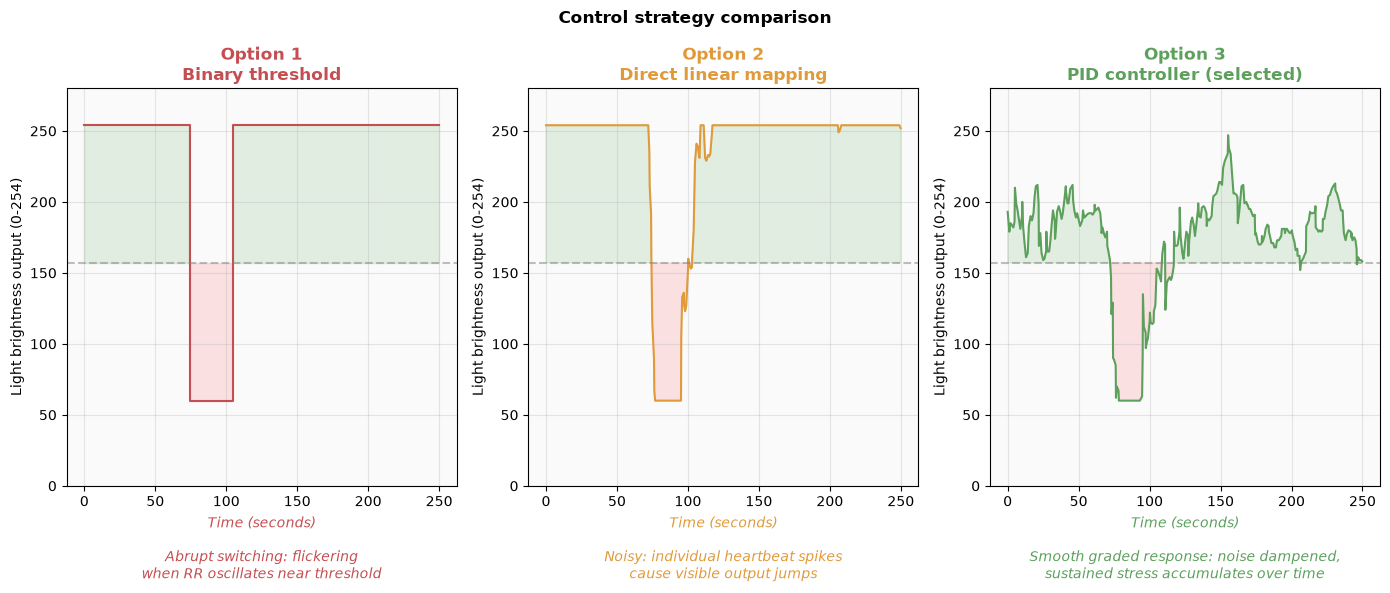

In [ ]:
# Converting lists to numpy arrays
time = np.array(time_seconds)
b_binary = np.array(binary_brightness)
b_linear = np.array(linear_brightness)
b_pid = np.array(pid_brightness)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6)) # creating a grid with 1 row and 3 columns
fig.suptitle("Control strategy comparison", fontweight="bold")

# Graph 1: Binary threshold
ax1.set_title("Option 1\nBinary threshold", fontweight="bold", color="#C44E52") # Assigning first graph title in red
ax1.step(time, b_binary, color="#C44E52", where="post") # .step to force rigid lines; jump tells the line to stay perfectly flat as it moves to the right, waiting until the exact moment it hits the next data point to make its vertical jump.

ax1.fill_between(time, b_binary, 157, where=(b_binary > 157), alpha=0.1, color="green", step="post") # alpha controls the transparency of the color (1.o=opaquw)
ax1.fill_between(time, b_binary, 157, where=(b_binary <= 157), alpha=0.1, color="red", step="post") # Colouring areas above/below threshold

ax1.set_xlabel("Time (seconds)\n\nAbrupt switching: flickering\nwhen RR oscillates near threshold", color="#C44E52", style="italic") # Labelling X axis and adding caption


# Graph 2: Linear mapping
ax2.set_title("Option 2\nDirect linear mapping", fontweight="bold", color="#E09A3A")
ax2.plot(time, b_linear, color="#E09A3A")

ax2.fill_between(time, b_linear, 157, where=(b_linear > 157), alpha=0.1, color="green")
ax2.fill_between(time, b_linear, 157, where=(b_linear <= 157), alpha=0.1, color="red")

ax2.set_xlabel("Time (seconds)\n\nNoisy: individual heartbeat spikes\ncause visible output jumps", color="#E09A3A", style="italic")


# Graph 3: PID
ax3.set_title("Option 3\nPID controller (selected)", fontweight="bold", color="#5CA05C")
ax3.plot(time, b_pid, color="#5CA05C")

ax3.fill_between(time, b_pid, 157, where=(b_pid > 157), alpha=0.1, color="green")
ax3.fill_between(time, b_pid, 157, where=(b_pid <= 157), alpha=0.1, color="red")

ax3.set_xlabel("Time (seconds)\n\nSmooth graded response: noise dampened,\nsustained stress accumulates over time", color="#5CA05C", style="italic")


# Applying the same formatting to all 3 graphs
for ax in (ax1, ax2, ax3):
    ax.axhline(157, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 280)
    ax.set_ylabel("Light brightness output (0-254)")
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_graphs.png", dpi=200, bbox_inches="tight")
print("Saved as comparison_graphs.png")
plt.show()